In [39]:
# imports and setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import re
import html
import unicodedata
import warnings
import time

from scipy.stats import spearmanr

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    average_precision_score,
    roc_auc_score
)
from sklearn.model_selection import KFold, cross_validate, cross_val_predict, train_test_split,RandomizedSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    make_scorer,
    median_absolute_error,
    explained_variance_score,
)
from scipy.stats import spearmanr, pearsonr
from xgboost import XGBRegressor


warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)


In [40]:
# find the raw json files

# path I use locally
json_dir = Path("../../raw_new")

# fallback when running in this notebook environment
if not json_dir.exists():
    json_dir = Path("/mnt/data")

# keep comment batches only; skip the tracker metadata file
json_files = sorted([
    p for p in json_dir.glob("*.json")
    if "scraped_videos_tracker" not in p.name
])

print("JSON directory:", json_dir.resolve())
print("Number of JSON files found:", len(json_files))
print([p.name for p in json_files[:5]])


JSON directory: /Users/hargun/Desktop/data-science/EarlySlangDetection/raw_new
Number of JSON files found: 75
['1STUD_batch_20260615_220936.json', '1STUD_batch_20260616_120929.json', '1STUD_batch_20260616_125913.json', '1STUD_batch_20260629_221901.json', 'AsmonTV_batch_20260608_205250.json']


In [41]:
# load the raw comment files

dfs = []

for json_file in json_files:
    temp = pd.read_json(json_file)

    # Example filename:
    #   MrBeastGaming_batch_20260608_205250.json
    # We extract:
    #   MrBeastGaming
    temp["channel_name"] = json_file.stem.split("_batch_")[0].replace("(1)", "")

    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

# basic cleanup
df["published_at"] = pd.to_datetime(df["published_at"], utc=True, errors="coerce")
df["likes"] = pd.to_numeric(df["likes"], errors="coerce").fillna(0).clip(lower=0).astype(int)
df["text"] = df["text"].fillna("").astype(str)

# no timestamp means no week assignment
df = df.dropna(subset=["published_at"]).reset_index(drop=True)

# simple comment id after cleaning
df["comment_id"] = df.index

display(df.head())
display(df.info())

print("Raw comments:", len(df))
print("Unique videos:", df["video_id"].nunique())
print("Unique channels:", df["channel_name"].nunique())


,video_id,text,likes,published_at,channel_name,comment_id
0,BSv6hna2Ycs,3:22 zenin clan treatment,49,2026-06-15 11:44:27+00:00,1STUD,0
1,BSv6hna2Ycs,your goat stud i wacht you 4 years,29,2026-06-15 11:03:58+00:00,1STUD,1
2,BSv6hna2Ycs,I WATCHED YA FOR 2 YEARS!!!,6,2026-06-15 12:03:19+00:00,1STUD,2
3,BSv6hna2Ycs,2:21 Bro Noob Army Being Like God Slayer😂,3,2026-06-15 14:31:33+00:00,1STUD,3
4,BSv6hna2Ycs,Yo stud even though you probably not going to ...,3,2026-06-15 14:24:59+00:00,1STUD,4


<class 'pandas.DataFrame'>
RangeIndex: 1739328 entries, 0 to 1739327
Data columns (total 6 columns):
 #   Column        Dtype              
---  ------        -----              
 0   video_id      str                
 1   text          str                
 2   likes         int64              
 3   published_at  datetime64[us, UTC]
 4   channel_name  str                
 5   comment_id    int64              
dtypes: datetime64[us, UTC](1), int64(2), str(3)
memory usage: 79.6 MB


None

Raw comments: 1739328
Unique videos: 19517
Unique channels: 32


In [42]:
NUM_WEEKS = 20
FUTURE_WEEKS = 3

# assign each comment to a week

latest = df["published_at"].max()

# week_back = 0 means most recent week.
# week_back = 1 means one week before the most recent week.
df["week_back"] = ((latest - df["published_at"]).dt.days // 7).astype(int)

# keep the most recent 20 weeks
df = df[(df["week_back"] >= 0) & (df["week_back"] < NUM_WEEKS)].copy().reset_index(drop=True)

# reset ids after filtering
df["comment_id"] = df.index

# make time_id run from old -> new
df["time_id"] = df["week_back"].max() - df["week_back"]

display(df[["comment_id", "published_at", "week_back", "time_id", "text", "likes"]].head())

print("Comments in 20-week window:", len(df))
print("time_id range:", df["time_id"].min(), "to", df["time_id"].max())


,comment_id,published_at,week_back,time_id,text,likes
0,0,2026-06-15 11:44:27+00:00,2,17,3:22 zenin clan treatment,49
1,1,2026-06-15 11:03:58+00:00,2,17,your goat stud i wacht you 4 years,29
2,2,2026-06-15 12:03:19+00:00,2,17,I WATCHED YA FOR 2 YEARS!!!,6
3,3,2026-06-15 14:31:33+00:00,2,17,2:21 Bro Noob Army Being Like God Slayer😂,3
4,4,2026-06-15 14:24:59+00:00,2,17,Yo stud even though you probably not going to ...,3


Comments in 20-week window: 373517
time_id range: 0 to 19


In [43]:
# tokenize comments

TOKEN_RE = re.compile(
    r"""
    (?<![a-z0-9])
    \#?
    (?:
        [a-z]+(?:['’‘ʼ`´＇-][a-z]+)*[a-z0-9]*
        |
        [a-z]*\d+[a-z0-9]*
    )
    (?![a-z0-9])
    """,
    re.I | re.VERBOSE
)

URL_RE = re.compile(r"https?://\S+|www\.\S+")
TIME_RE = re.compile(r"\b\d{1,2}:\d{2}(?::\d{2})?\b")

APOSTROPHE_TRANSLATION = str.maketrans({
    "’": "'",
    "‘": "'",
    "ʼ": "'",
    "`": "'",
    "´": "'",
    "＇": "'"
})

def tokenize(text):
    """Basic tokenizer for comment text."""
    text = html.unescape(str(text))
    text = unicodedata.normalize("NFKC", text)
    text = text.translate(APOSTROPHE_TRANSLATION)
    text = text.lower()
    text = URL_RE.sub(" ", text)
    text = TIME_RE.sub(" ", text)

    tokens = [m.group(0).lstrip("#") for m in TOKEN_RE.finditer(text)]

    # Remove tokens that are only digits
    tokens = [t for t in tokens if not t.isdigit()]

    return tokens

df["tokens"] = df["text"].apply(tokenize)

display(df[["text", "tokens"]].sample(10, random_state=42))


,text,tokens
115493,Day 7 of asking for a fractal block world theory,"[day, of, asking, for, a, fractal, block, worl..."
247243,Interesting,[interesting]
179793,“as of 2024” okay. so wheres the updated chart?,"[as, of, okay, so, wheres, the, updated, chart]"
329339,"Ryan Cohen, trust the process","[ryan, cohen, trust, the, process]"
370479,Hissan wouldve captured this guy easy once the...,"[hissan, wouldve, captured, this, guy, easy, o..."
175703,Imagine jumping as a casual Morse code for bei...,"[imagine, jumping, as, a, casual, morse, code,..."
256504,The whole game in one trailer!!! Nice,"[the, whole, game, in, one, trailer, nice]"
157569,28:37 TIMMEH????,[timmeh]
362904,We’ve seen this already bro ♻️,"[we've, seen, this, already, bro]"
194213,Continue Playing Red Dead Redemption 2 we all ...,"[continue, playing, red, dead, redemption, we,..."


In [44]:
# one word per comment

df_words = df.explode("tokens").rename(columns={"tokens": "word"})
df_words = df_words.dropna(subset=["word"])
df_words = df_words[df_words["word"].str.len() > 0].copy()

# count a word only once per comment
df_unique = df_words.drop_duplicates(["comment_id", "word", "time_id"])

display(df_words[["comment_id", "word", "likes", "time_id", "video_id"]].head())
display(df_unique[["comment_id", "word", "likes", "time_id", "video_id"]].head())

print("Word occurrences before de-duplication:", len(df_words))
print("Unique comment-word-week rows after de-duplication:", len(df_unique))


,comment_id,word,likes,time_id,video_id
0,0,zenin,49,17,BSv6hna2Ycs
0,0,clan,49,17,BSv6hna2Ycs
0,0,treatment,49,17,BSv6hna2Ycs
1,1,your,29,17,BSv6hna2Ycs
1,1,goat,29,17,BSv6hna2Ycs


,comment_id,word,likes,time_id,video_id
0,0,zenin,49,17,BSv6hna2Ycs
0,0,clan,49,17,BSv6hna2Ycs
0,0,treatment,49,17,BSv6hna2Ycs
1,1,your,29,17,BSv6hna2Ycs
1,1,goat,29,17,BSv6hna2Ycs


Word occurrences before de-duplication: 4765317
Unique comment-word-week rows after de-duplication: 4252512


In [45]:
# --------------------------------------------------
# Build stopword list
# --------------------------------------------------

stopwords = set("""
a about above after again against all am an and any are as at be because been before being below between both but by
can cannot could did do does doing down during each few for from further had has have having he her here hers herself
him himself his how i if in into is it its itself just me more most my myself no nor not of off on once only or other
our ours ourselves out over own same she should so some such than that the their theirs them themselves then there
these they this those through to too under until up very was we were what when where which while who whom why will
with you your yours yourself yourselves
""".split())

stopwords |= {
    "i'm","it's","that's","don't","you're","he's","she's","we're","they're",
    "i've","you've","we've","they've","i'll","you'll","we'll","they'll",
    "isn't","aren't","wasn't","weren't","can't","couldn't","wouldn't",
    "shouldn't","won't","didn't","doesn't","haven't","hasn't","hadn't",
    "there's","what's","who's","where's","when's","why's","how's",
    "im","ive","dont","cant","wont","youre","thats","theres","whats",
    "hes","shes","were","theyre","ll","re","ve","ur","amp"
}

stopwords |= {
    "would","one","get","even","video","go","know","never","got","good",
    "make","made","see","think","really","still","also","much","going",
    "people","bro","man","guys","time","way","back","first","last",
    "like","game","person","now","years","guy","kid","thing","stuff",
    "day","watch","look","looks","say","said","right","actually"
}



In [50]:

# Build one-row-per-word feature table 

weeks = list(range(NUM_WEEKS))

feature_weeks = list(range(NUM_WEEKS - FUTURE_WEEKS))

future_weeks = list(range(NUM_WEEKS - FUTURE_WEEKS, NUM_WEEKS))

eps_count = 1.0
eps_rel = 1e-10


weekly_comments = (
    df.groupby("time_id")["comment_id"]
    .nunique()
    .reindex(weeks)
    .fillna(0)
)

weekly_likes = (
    df.groupby("time_id")["likes"]
    .sum()
    .reindex(weeks)
    .fillna(0)
)


# Helper to make word x week matrices
def word_week_matrix(values=None, aggfunc="size"):
    if aggfunc == "size":
        mat = (
            df_unique
            .groupby(["word", "time_id"])
            .size()
            .unstack("time_id")
        )
    else:
        mat = (
            df_unique
            .pivot_table(
                index="word",
                columns="time_id",
                values=values,
                aggfunc=aggfunc
            )
        )

    mat = mat.reindex(columns=weeks).fillna(0)
    return mat


# Raw word-week matrices
count_mat = word_week_matrix(aggfunc="size")
likes_mat = word_week_matrix(values="likes", aggfunc="sum")
avg_likes_mat = word_week_matrix(values="likes", aggfunc="mean")
n_videos_mat = word_week_matrix(values="video_id", aggfunc=pd.Series.nunique)
n_channels_mat = word_week_matrix(values="channel_name", aggfunc=pd.Series.nunique)

avg_likes_mat = avg_likes_mat.fillna(0)
n_videos_mat = n_videos_mat.fillna(0)
n_channels_mat = n_channels_mat.fillna(0)

# Relative frequency and relative likes
rel_freq_mat = count_mat.div(weekly_comments.replace(0, np.nan), axis=1).fillna(0)
rel_likes_mat = likes_mat.div(weekly_likes.replace(0, np.nan), axis=1).fillna(0)


# Filter words
before_words = len(count_mat)

valid_words = [
    w for w in count_mat.index
    if (w not in stopwords) and (len(w) >= 2 or w in {"w", "l"})
]

count_mat = count_mat.loc[valid_words]
likes_mat = likes_mat.loc[valid_words]
avg_likes_mat = avg_likes_mat.loc[valid_words]
n_videos_mat = n_videos_mat.loc[valid_words]
n_channels_mat = n_channels_mat.loc[valid_words]
rel_freq_mat = rel_freq_mat.loc[valid_words]
rel_likes_mat = rel_likes_mat.loc[valid_words]

# keep words that appear at least 5 times in at least one week
keep_words = count_mat.index[count_mat.max(axis=1) >= 5]

count_mat = count_mat.loc[keep_words]
likes_mat = likes_mat.loc[keep_words]
avg_likes_mat = avg_likes_mat.loc[keep_words]
n_videos_mat = n_videos_mat.loc[keep_words]
n_channels_mat = n_channels_mat.loc[keep_words]
rel_freq_mat = rel_freq_mat.loc[keep_words]
rel_likes_mat = rel_likes_mat.loc[keep_words]

print("Unique words before filtering:", before_words)
print("Unique words after filtering:", len(keep_words))


# Make one wide dataframe
wide_parts = []

for name, mat in {
    "count": count_mat,
    "likes": likes_mat,
    "avg_likes": avg_likes_mat,
    "n_videos": n_videos_mat,
    "n_channels": n_channels_mat,
    "rel_freq": rel_freq_mat,
    "rel_likes": rel_likes_mat,
}.items():
    temp = mat.copy()
    temp.columns = [f"week_{i}_{name}" for i in temp.columns]
    wide_parts.append(temp)

wide = pd.concat(wide_parts, axis=1).fillna(0)

print("wide shape:", wide.shape)


# Target y
# X uses feature_weeks
# y uses future_weeks
past_rel_cols = [f"week_{i}_rel_freq" for i in feature_weeks]
future_rel_cols = [f"week_{i}_rel_freq" for i in future_weeks]

past_avg = wide[past_rel_cols].mean(axis=1)
future_avg = wide[future_rel_cols].mean(axis=1)

y = np.log((future_avg + eps_rel) / (past_avg + eps_rel))


# Build X from feature_weeks only
features = {}

base_vars = [
    "count",
    "likes",
    "avg_likes",
    "n_videos",
    "n_channels",
    "rel_freq",
    "rel_likes",
]

# raw histories
for var in base_vars:
    for i in feature_weeks:
        features[f"week_{i}_{var}"] = wide[f"week_{i}_{var}"]

# log growth features
for var in ["count", "likes", "avg_likes", "n_videos", "n_channels"]:
    for i in feature_weeks[1:]:
        features[f"{var}_log_growth_{i}_{i-1}"] = np.log(
            (wide[f"week_{i}_{var}"] + eps_count)
            / (wide[f"week_{i-1}_{var}"] + eps_count)
        )

for var in ["rel_freq", "rel_likes"]:
    for i in feature_weeks[1:]:
        features[f"{var}_log_growth_{i}_{i-1}"] = np.log(
            (wide[f"week_{i}_{var}"] + eps_rel)
            / (wide[f"week_{i-1}_{var}"] + eps_rel)
        )

# likes per comment
for i in feature_weeks:
    features[f"likes_per_comment_{i}"] = (
        wide[f"week_{i}_likes"] / (wide[f"week_{i}_count"] + eps_count)
    )

# summary features
count_cols = [f"week_{i}_count" for i in feature_weeks]
rel_cols = [f"week_{i}_rel_freq" for i in feature_weeks]
like_cols = [f"week_{i}_likes" for i in feature_weeks]
video_cols = [f"week_{i}_n_videos" for i in feature_weeks]
channel_cols = [f"week_{i}_n_channels" for i in feature_weeks]

features["weeks_nonzero"] = (wide[count_cols] > 0).sum(axis=1)

features["count_mean"] = wide[count_cols].mean(axis=1)
features["count_std"] = wide[count_cols].std(axis=1)
features["count_max"] = wide[count_cols].max(axis=1)

features["rel_freq_mean"] = wide[rel_cols].mean(axis=1)
features["rel_freq_std"] = wide[rel_cols].std(axis=1)
features["rel_freq_max"] = wide[rel_cols].max(axis=1)

features["likes_mean"] = wide[like_cols].mean(axis=1)
features["likes_std"] = wide[like_cols].std(axis=1)
features["likes_max"] = wide[like_cols].max(axis=1)

features["n_videos_mean"] = wide[video_cols].mean(axis=1)
features["n_videos_max"] = wide[video_cols].max(axis=1)

# recent momentum
recent_weeks = feature_weeks[-3:]
prev_weeks = feature_weeks[-6:-3]

features["rel_freq_recent3_mean"] = wide[[f"week_{i}_rel_freq" for i in recent_weeks]].mean(axis=1)
features["rel_freq_prev3_mean"] = wide[[f"week_{i}_rel_freq" for i in prev_weeks]].mean(axis=1)
features["rel_freq_momentum_3w"] = (
    features["rel_freq_recent3_mean"] - features["rel_freq_prev3_mean"]
)

features["likes_recent3_mean"] = wide[[f"week_{i}_likes" for i in recent_weeks]].mean(axis=1)
features["likes_prev3_mean"] = wide[[f"week_{i}_likes" for i in prev_weeks]].mean(axis=1)
features["likes_momentum_3w"] = (
    features["likes_recent3_mean"] - features["likes_prev3_mean"]
)

# slopes
week_nums = np.array(feature_weeks)

def slope(row):
    return np.polyfit(week_nums, row.values, 1)[0]

features["rel_freq_slope"] = wide[rel_cols].apply(slope, axis=1)
features["count_slope"] = wide[count_cols].apply(slope, axis=1)
features["likes_slope"] = wide[like_cols].apply(slope, axis=1)

X = pd.DataFrame(features, index=wide.index)
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("y summary:")
print(y.describe())



Unique words before filtering: 102964
Unique words after filtering: 11003
wide shape: (11003, 140)
X shape: (11003, 269)
y shape: (11003,)
y summary:
count    11003.000000
mean        -2.510809
std          4.901129
min        -16.230565
25%         -1.806201
50%         -0.697033
75%         -0.052784
max         16.050188
dtype: float64


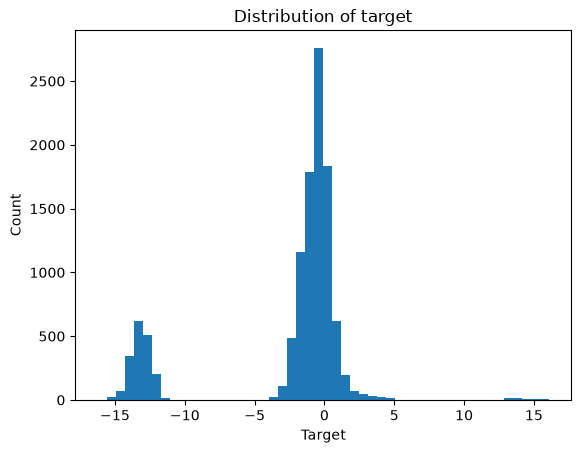

In [51]:
plt.hist(y, bins=50)
plt.xlabel("Target")
plt.ylabel("Count")
plt.title("Distribution of target")
plt.show()

Remaining samples: 9167
count    9167.000000
mean       -0.516468
std         1.043402
min        -4.275009
25%        -1.159100
50%        -0.485948
75%         0.045163
max         6.268784
dtype: float64
count    7333.000000
mean       -0.510473
std         1.050657
min        -4.275009
25%        -1.150351
50%        -0.483541
75%         0.046478
max         6.268784
dtype: float64


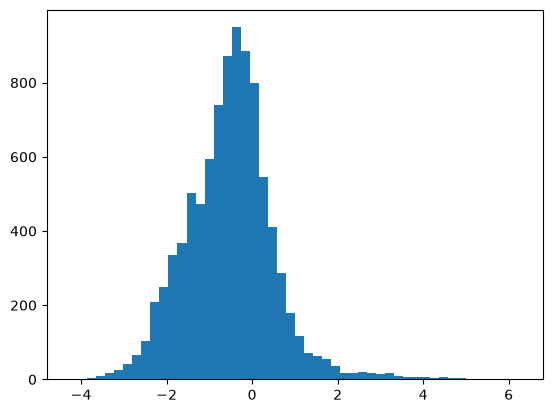

In [54]:
# Keep only observations with target between -8 and 8
mask = (y >= -8) & (y <= 8)

X = X.loc[mask].copy()
y = y.loc[mask].copy()

print(f"Remaining samples: {len(y)}")
print(y.describe())
plt.hist(y, bins = 50)


X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(y_train.describe())

In [55]:
def spearman_score(y_true, y_pred):
    return spearmanr(y_true, y_pred).statistic

def pearson_score(y_true, y_pred):
    return pearsonr(y_true, y_pred)[0]

cv = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "dummy_mean": DummyRegressor(strategy="mean"),

    "dummy_median": DummyRegressor(strategy="median"),
    
    "linear": make_pipeline(
        StandardScaler(),
        LinearRegression()
    ),

    "ridge": make_pipeline(
        StandardScaler(),
        Ridge(alpha=1.0)
    ),

    "lasso": make_pipeline(
        StandardScaler(),
        Lasso(alpha=0.001, max_iter=10000)
    ),

    "random_forest": RandomForestRegressor(
        n_estimators=500,
        max_depth=12,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ),

    "extra_trees": ExtraTreesRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "hist_gradient_boosting": HistGradientBoostingRegressor(
        max_iter=500,
        learning_rate=0.03,
        max_leaf_nodes=31,
        random_state=42
    ),

    "xgboost": XGBRegressor(
        objective="reg:squarederror",
        n_estimators=600,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        reg_alpha=0.0,
        random_state=42,
        n_jobs=-1
    ),

    "mlp_small": make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            alpha=1e-4,
            learning_rate_init=1e-3,
            batch_size=128,
            max_iter=500,
            early_stopping=True,
            validation_fraction=0.15,
            random_state=42
        )
    ),

    "mlp_large": make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=(256, 128, 64),
            activation="relu",
            alpha=1e-4,
            learning_rate_init=5e-4,
            batch_size=128,
            max_iter=600,
            early_stopping=True,
            validation_fraction=0.15,
            random_state=42
        )
    ),
}

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "medae": make_scorer(
        median_absolute_error,
        greater_is_better=False
    ),
    "r2": "r2",
    "explained_variance": make_scorer(
        explained_variance_score
    ),
    "spearman": make_scorer(spearman_score),
    "pearson": make_scorer(pearson_score),
}

rows = []

for name, model in models.items():

    print(f"Training {name}...")

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=True
    )

    rows.append({
        "model": name,

        "train_rmse_mean": -scores["train_rmse"].mean(),
        "train_rmse_std": scores["train_rmse"].std(),

        "test_rmse_mean": -scores["test_rmse"].mean(),
        "test_rmse_std": scores["test_rmse"].std(),

        "test_mae_mean": -scores["test_mae"].mean(),
        "test_mae_std": scores["test_mae"].std(),

        "test_median_ae_mean": -scores["test_medae"].mean(),
        "test_median_ae_std": scores["test_medae"].std(),

        "test_r2_mean": scores["test_r2"].mean(),
        "test_r2_std": scores["test_r2"].std(),

        "test_explained_variance_mean": scores["test_explained_variance"].mean(),
        "test_explained_variance_std": scores["test_explained_variance"].std(),

        "test_spearman_mean": scores["test_spearman"].mean(),
        "test_spearman_std": scores["test_spearman"].std(),

        "test_pearson_mean": scores["test_pearson"].mean(),
        "test_pearson_std": scores["test_pearson"].std(),
    })

cv_results = (
    pd.DataFrame(rows)
    .sort_values("test_spearman_mean", ascending=False)
    .reset_index(drop=True)
)

cv_results


Training dummy_mean...
Training dummy_median...
Training linear...
Training ridge...
Training lasso...
Training random_forest...
Training extra_trees...
Training hist_gradient_boosting...
Training xgboost...
Training mlp_small...
Training mlp_large...


,model,train_rmse_mean,train_rmse_std,test_rmse_mean,test_rmse_std,test_mae_mean,test_mae_std,test_median_ae_mean,test_median_ae_std,test_r2_mean,test_r2_std,test_explained_variance_mean,test_explained_variance_std,test_spearman_mean,test_spearman_std,test_pearson_mean,test_pearson_std
0,xgboost,0.482088,0.005355,0.864512,0.014927,0.671436,0.012503,0.544306,0.017227,0.321184,0.024381,3.213198e-01,2.438682e-02,0.407296,0.010568,0.568247,0.019836
1,hist_gradient_boosting,0.416889,0.002660,0.868919,0.017142,0.674830,0.014451,0.548494,0.023130,0.314405,0.021729,3.145856e-01,2.182457e-02,0.400344,0.009926,0.562894,0.017918
2,random_forest,0.595981,0.010662,0.866417,0.017561,0.679074,0.014534,0.559307,0.016619,0.318392,0.020592,3.186499e-01,2.061200e-02,0.399969,0.017412,0.565504,0.019103
3,extra_trees,0.097507,0.001461,0.870985,0.018002,0.678043,0.014204,0.550935,0.016473,0.310970,0.027656,3.111594e-01,2.764197e-02,0.392803,0.010366,0.559194,0.026395
4,lasso,0.938668,0.008350,0.965512,0.032925,0.743124,0.019271,0.589091,0.016609,0.154511,0.010468,1.545566e-01,1.044951e-02,0.328497,0.009254,0.396335,0.011709
5,ridge,0.933291,0.008506,0.971393,0.035545,0.748537,0.021565,0.598836,0.018901,0.144283,0.013664,1.443073e-01,1.365884e-02,0.326780,0.004756,0.389512,0.013807
6,linear,0.933127,0.008531,0.972197,0.036151,0.749155,0.022043,0.597119,0.017945,0.142890,0.014598,1.429136e-01,1.459740e-02,0.325823,0.004863,0.388498,0.014659
7,mlp_large,0.788250,0.042383,0.970941,0.020575,0.749002,0.016540,0.598571,0.025503,0.144084,0.024182,1.446480e-01,2.388407e-02,0.289933,0.023731,0.406253,0.018394
8,mlp_small,0.808962,0.025890,0.971502,0.025234,0.748929,0.017957,0.595521,0.020500,0.143464,0.017267,1.436075e-01,1.715028e-02,0.284959,0.011027,0.400354,0.021490
9,dummy_mean,1.050547,0.008325,1.050114,0.033051,0.778350,0.019730,0.594311,0.021778,-0.000251,0.000116,1.776357e-16,8.881784e-17,NaN,NaN,NaN,NaN


In [ ]:
#SKIP RUNNING THIS CELL UNLESS RETUNING HYPERPARAMETERS (TAKES >4 HRS)
#nestedCV
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)

tuning_models = {
    "xgboost": {
        "model": XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ),
        "params": {
            "n_estimators": [400, 600, 800],
            "max_depth": [3, 4, 5, 6],
            "learning_rate": [0.01, 0.03, 0.05],
            "subsample": [0.7, 0.8, 1.0],
            "colsample_bytree": [0.7, 0.8, 1.0],
            "reg_lambda": [0.5, 1.0, 2.0],
            "reg_alpha": [0.0, 0.01, 0.1],
            "min_child_weight": [1, 3, 5],
        }
    },

    # "random_forest": {
    #     "model": RandomForestRegressor(random_state=42, n_jobs=-1),
    #     "params": {
    #         "n_estimators": [300, 500, 700],
    #         "max_depth": [8, 12, 16, None],
    #         "min_samples_leaf": [1, 2, 3, 5],
    #         "min_samples_split": [2, 5, 10],
    #         "max_features": ["sqrt", "log2", 0.5, 0.8],
    #     }
    # },

    # "extra_trees": {
    #     "model": ExtraTreesRegressor(random_state=42, n_jobs=-1),
    #     "params": {
    #         "n_estimators": [300, 500, 700],
    #         "max_depth": [8, 12, 16, None],
    #         "min_samples_leaf": [1, 2, 3, 5],
    #         "min_samples_split": [2, 5, 10],
    #         "max_features": ["sqrt", "log2", 0.5, 0.8],
    #     }
    # },

    # "hist_gradient_boosting": {
    #     "model": HistGradientBoostingRegressor(random_state=42),
    #     "params": {
    #         "max_iter": [300, 500, 700],
    #         "learning_rate": [0.01, 0.03, 0.05],
    #         "max_leaf_nodes": [15, 31, 63],
    #         "min_samples_leaf": [10, 20, 30, 50],
    #         "l2_regularization": [0.0, 0.01, 0.1, 1.0],
    #     }
    # },
}

nested_rows = []

for name, item in tuning_models.items():
    print(f"Tuning {name}...")

    search = RandomizedSearchCV(
        estimator=item["model"],
        param_distributions=item["params"],
        n_iter=25,
        scoring="neg_root_mean_squared_error",
        cv=inner_cv,
        random_state=42,
        n_jobs=-1,
        refit=True,
        verbose=1
    )

    scores = cross_validate(
        search,
        X_train,
        y_train,
        cv=outer_cv,
        scoring=scoring,
        n_jobs=-1,
        return_estimator=True
    )

    nested_rows.append({
        "model": name,
        "nested_rmse_mean": -scores["test_rmse"].mean(),
        "nested_rmse_std": scores["test_rmse"].std(),
        "nested_mae_mean": -scores["test_mae"].mean(),
        "nested_mae_std": scores["test_mae"].std(),
        "nested_r2_mean": scores["test_r2"].mean(),
        "nested_r2_std": scores["test_r2"].std(),
        "nested_spearman_mean": scores["test_spearman"].mean(),
        "nested_spearman_std": scores["test_spearman"].std(),
        "nested_pearson_mean": scores["test_pearson"].mean(),
        "nested_pearson_std": scores["test_pearson"].std(),
    })

nested_results = (
    pd.DataFrame(nested_rows)
    .sort_values("nested_rmse_mean")
    .reset_index(drop=True)
)

nested_results

Tuning xgboost...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Fitting 5 folds for each of 25 candidates, totalling 125 fits


,model,nested_rmse_mean,nested_rmse_std,nested_mae_mean,nested_mae_std,nested_r2_mean,nested_r2_std,nested_spearman_mean,nested_spearman_std,nested_pearson_mean,nested_pearson_std
0,xgboost,0.860428,0.0187,0.672467,0.014655,0.327849,0.019491,0.411207,0.00733,0.573449,0.017668


In [57]:
best_model_name = nested_results.loc[0, "model"]
print("Best model:", best_model_name)

best_item = tuning_models[best_model_name]

final_search = RandomizedSearchCV(
    estimator=best_item["model"],
    param_distributions=best_item["params"],
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=inner_cv,
    random_state=42,
    n_jobs=-1,
    refit=True,
    verbose=1
)

final_search.fit(X_train, y_train)

best_model = final_search.best_estimator_

print("Best params:")
print(final_search.best_params_)
print("Best train-CV RMSE:", -final_search.best_score_)

Best model: xgboost
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params:
{'subsample': 0.7, 'reg_lambda': 2.0, 'reg_alpha': 0.1, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Best train-CV RMSE: 0.8588226612568292


In [ ]:
# current best model
#model = RandomForestRegressor(
#    n_estimators=300,
#    max_depth=12,
#    min_samples_leaf=3,
#    random_state=42,
#    n_jobs=-1
#)

#obtained after running last 2 cells
best_model = XGBRegressor(
    objective="reg:squarederror",
    subsample=0.7,
    reg_lambda=2.0,
    reg_alpha=0.1,
    n_estimators=800,
    min_child_weight=1,
    max_depth=5,
    learning_rate=0.01,
    colsample_bytree=1.0,
    random_state=42,
    n_jobs=-1
)
model = best_model

# out-of-fold predictions
y_train_pred = cross_val_predict(
    model,
    X_train,
    y_train,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)

eval_df = pd.DataFrame({
    "word": X_train.index,
    "y_true": y_train,
    "y_pred": y_train_pred
}).reset_index(drop=True)

# sanity-check metrics
print("RMSE:", mean_squared_error(eval_df["y_true"], eval_df["y_pred"]) ** 0.5)
print("MAE:", mean_absolute_error(eval_df["y_true"], eval_df["y_pred"]))
print("R2:", r2_score(eval_df["y_true"], eval_df["y_pred"]))
print("Spearman:", spearmanr(eval_df["y_true"], eval_df["y_pred"]).statistic)
print("Pearson:", pearsonr(eval_df["y_true"], eval_df["y_pred"])[0])


RMSE: 0.8590257912341696
MAE: 0.6708697869970525
R2: 0.33142506177010556
Spearman: 0.41513411535270883
Pearson: 0.5758433628489317


In [59]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)

print("\nDummy baseline")
print("--------------")
print("RMSE:", mean_squared_error(y_test, dummy_pred) ** 0.5)
print("MAE:", mean_absolute_error(y_test, dummy_pred))
print("R2:", r2_score(y_test, dummy_pred))


Dummy baseline
--------------
RMSE: 1.0139684578096932
MAE: 0.7569444257515097
R2: -0.0008742052845975845


In [60]:
# Train on the full training set
best_model.fit(X_train, y_train)

# Predict on the held-out test set
y_test_pred = best_model.predict(X_test)

# Create dataframe for analysis
test_eval_df = pd.DataFrame({
    "word": X_test.index,
    "y_true": y_test,
    "y_pred": y_test_pred
}).reset_index(drop=True)

# Overall metrics
print("Final Test Performance")
print("----------------------")
print("RMSE:", mean_squared_error(y_test, y_test_pred) ** 0.5)
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("Median AE:", median_absolute_error(y_test, y_test_pred))
print("R2:", r2_score(y_test, y_test_pred))
print("Explained Variance:", explained_variance_score(y_test, y_test_pred))
print("Spearman:", spearmanr(y_test, y_test_pred).statistic)
print("Pearson:", pearsonr(y_test, y_test_pred)[0])

Final Test Performance
----------------------
RMSE: 0.842596881106701
MAE: 0.6575757417742077
Median AE: 0.5403023292411082
R2: 0.30885320169395003
Explained Variance: 0.30905213702802103
Spearman: 0.40658328741523053
Pearson: 0.5559417179320054


In [61]:
def ranking_eval(df, k):
    top_pred = df.sort_values("y_pred", ascending=False).head(k)
    top_true = df.sort_values("y_true", ascending=False).head(k)

    top_true_words = set(top_true["word"])
    precision_at_k = top_pred["word"].isin(top_true_words).mean()

    return {
        "k": k,
        "overlap_count": int(top_pred["word"].isin(top_true_words).sum()),
        "precision_at_k": precision_at_k,
        "avg_true_y_pred_topk": top_pred["y_true"].mean(),
        "avg_true_y_ideal_topk": top_true["y_true"].mean(),
        "median_true_y_pred_topk": top_pred["y_true"].median(),
        "median_true_y_ideal_topk": top_true["y_true"].median(),
    }

ranking_results = pd.DataFrame([
    ranking_eval(test_eval_df, k)
    for k in [10, 20, 50, 100, 200]
])

ranking_results


,k,overlap_count,precision_at_k,avg_true_y_pred_topk,avg_true_y_ideal_topk,median_true_y_pred_topk,median_true_y_ideal_topk
0,10,7,0.700,3.600876,4.195085,4.021072,4.293980
1,20,11,0.550,2.825822,3.488850,2.622027,3.105863
2,50,29,0.580,2.029072,2.464316,1.594042,2.129517
3,100,45,0.450,1.009024,1.776626,0.747824,1.413622
4,200,83,0.415,0.462648,1.212830,0.258224,0.877598


In [62]:
test_eval_df.sort_values("y_pred", ascending=False).head(50)


,word,y_true,y_pred
1046,minidicks,3.840317,3.766216
1117,rasengan,5.208034,3.741395
1533,ky,4.595918,3.643114
706,kh4,4.201828,3.304336
1521,ether,1.774483,3.276982
1556,ashe,1.703524,3.236605
772,bolin,4.386132,3.044776
787,zlatan,2.632490,2.943704
1367,galio,4.547343,2.772355
905,spurs,3.118689,2.722113


In [63]:
test_eval_df.sort_values("y_true", ascending=False).head(50)


,word,y_true,y_pred
1117,rasengan,5.208034,3.741395
1533,ky,4.595918,3.643114
1367,galio,4.547343,2.772355
1089,nanami,4.519630,0.784310
772,bolin,4.386132,3.044776
706,kh4,4.201828,3.304336
1046,minidicks,3.840317,3.766216
331,locke,3.823683,-0.039481
898,madden,3.709278,1.434450
905,spurs,3.118689,2.722113


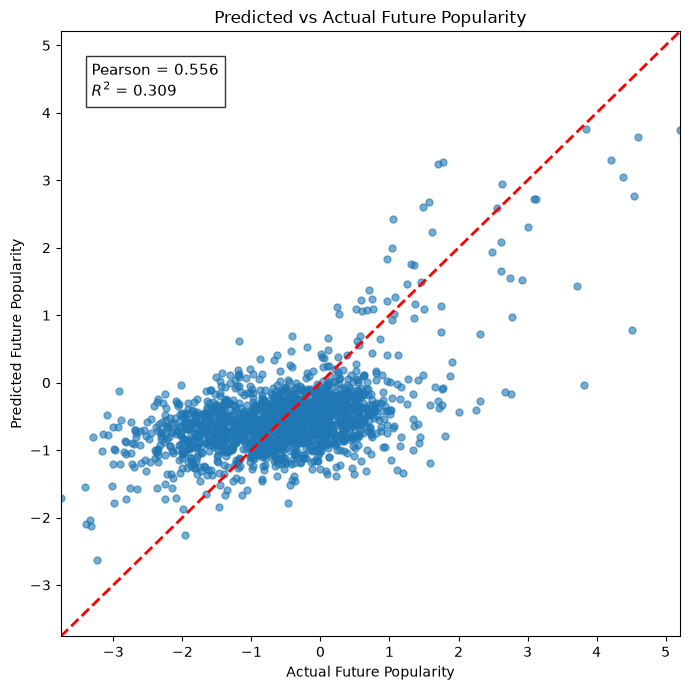

In [64]:
r = pearsonr(test_eval_df["y_true"], test_eval_df["y_pred"])[0]
r2 = r2_score(test_eval_df["y_true"], test_eval_df["y_pred"])

plt.figure(figsize=(7,7))

plt.scatter(
    test_eval_df["y_true"],
    test_eval_df["y_pred"],
    alpha=0.6,
    s=25
)

lims = [
    min(test_eval_df["y_true"].min(), eval_df["y_pred"].min()),
    max(test_eval_df["y_true"].max(), eval_df["y_pred"].max())
]
plt.plot(lims, lims, "r--", lw=2)

plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("Actual Future Popularity")
plt.ylabel("Predicted Future Popularity")
plt.title("Predicted vs Actual Future Popularity")

plt.text(
    0.05,
    0.95,
    f"Pearson = {r:.3f}\n$R^2$ = {r2:.3f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve, 
    precision_recall_curve
)



# Define viral = top 20% true y


viral_quantile = 0.80

true_threshold = test_eval_df["y_true"].quantile(viral_quantile)
pred_threshold = test_eval_df["y_pred"].quantile(viral_quantile)

classification_df = test_eval_df.copy()

classification_df["true_viral"] = (
    classification_df["y_true"] >= true_threshold
).astype(int)

classification_df["pred_viral"] = (
    classification_df["y_pred"] >= true_threshold
).astype(int)

y_true_binary = classification_df["true_viral"]
y_pred_binary = classification_df["pred_viral"]
y_score = classification_df["y_pred"]


# Regression metrics on top 20%


top20_df = classification_df[classification_df["true_viral"] == 1]

top20_regression_metrics = pd.DataFrame([{
    "group": "true_top20_y",
    "n_words": len(top20_df),
    "rmse": mean_squared_error(top20_df["y_true"], top20_df["y_pred"]) ** 0.5,
    "mae": mean_absolute_error(top20_df["y_true"], top20_df["y_pred"]),
    "median_ae": median_absolute_error(top20_df["y_true"], top20_df["y_pred"]),
    "r2": r2_score(top20_df["y_true"], top20_df["y_pred"]),
    "explained_variance": explained_variance_score(top20_df["y_true"], top20_df["y_pred"]),
    "pearson": pearsonr(top20_df["y_true"], top20_df["y_pred"])[0],
    "spearman": spearmanr(top20_df["y_true"], top20_df["y_pred"]).statistic,
}])

top20_regression_metrics

,group,n_words,rmse,mae,median_ae,r2,explained_variance,pearson,spearman
0,true_top20_y,367,1.165975,1.012661,0.957669,-1.107065,0.213065,0.661269,0.337921


In [ ]:

# Classification metrics


cm = confusion_matrix(y_true_binary, y_pred_binary)

tn, fp, fn, tp = cm.ravel()

classification_metrics = pd.DataFrame([{
    "viral_definition": "top 20% by true y",
    "true_y_threshold": true_threshold,
    "pred_y_threshold": pred_threshold,
    "n_test_words": len(classification_df),
    "true_viral_words": int(y_true_binary.sum()),
    "predicted_viral_words": int(y_pred_binary.sum()),
    "true_positives": int(tp),
    "false_positives": int(fp),
    "false_negatives": int(fn),
    "true_negatives": int(tn),
    "accuracy": accuracy_score(y_true_binary, y_pred_binary),
    "precision": precision_score(y_true_binary, y_pred_binary),
    "recall": recall_score(y_true_binary, y_pred_binary),
    "f1": f1_score(y_true_binary, y_pred_binary),
    "roc_auc": roc_auc_score(y_true_binary, y_score),
}])

classification_metrics

,viral_definition,true_y_threshold,pred_y_threshold,n_test_words,true_viral_words,predicted_viral_words,true_positives,false_positives,false_negatives,true_negatives,accuracy,precision,recall,f1,roc_auc
0,top 20% by true y,0.168406,-0.290663,1834,367,86,65,21,302,1446,0.823882,0.755814,0.177112,0.286976,0.70562


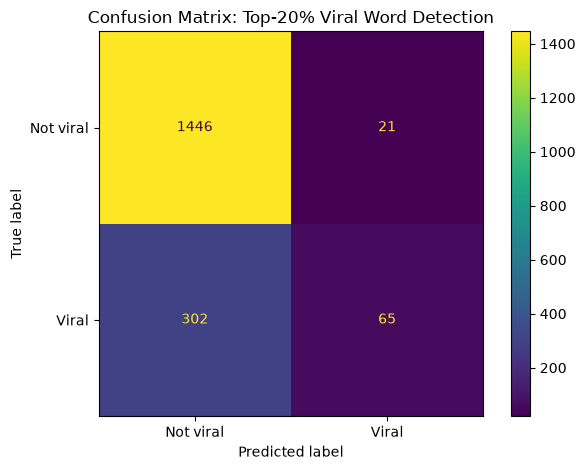

In [ ]:

# Confusion matrix plot


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not viral", "Viral"]
)

disp.plot()
plt.title("Confusion Matrix: Top-20% Viral Word Detection")
plt.tight_layout()
plt.show()

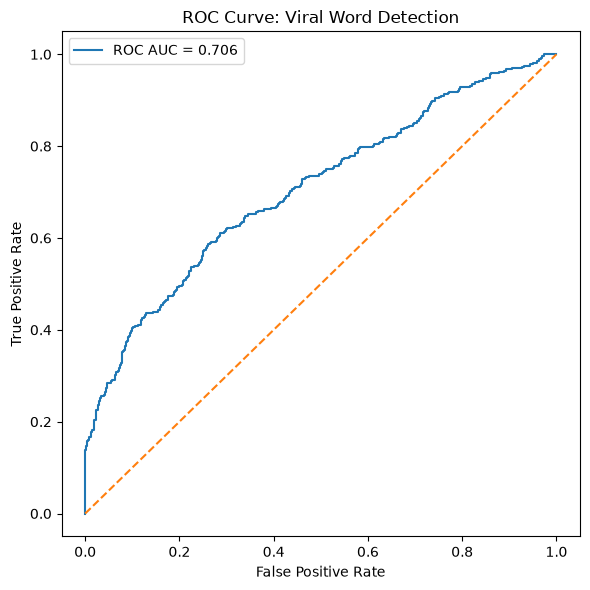

In [ ]:
# ROC curve


fpr, tpr, thresholds = roc_curve(y_true_binary, y_score)
auc = roc_auc_score(y_true_binary, y_score)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Viral Word Detection")
plt.legend()
plt.tight_layout()
plt.show()

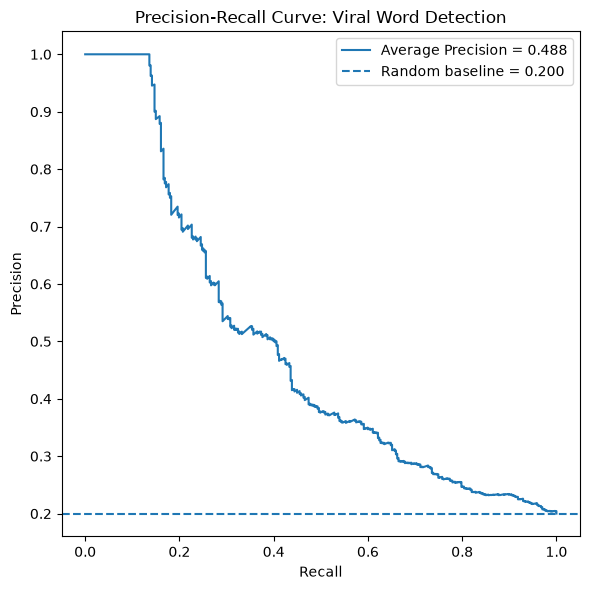

In [69]:
precision, recall, thresholds = precision_recall_curve(y_true_binary, y_score)
ap = average_precision_score(y_true_binary, y_score)

plt.figure(figsize=(6, 6))
plt.plot(recall, precision, label=f"Average Precision = {ap:.3f}")

baseline = y_true_binary.mean()
plt.axhline(baseline, linestyle="--", label=f"Random baseline = {baseline:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve: Viral Word Detection")
plt.legend()
plt.tight_layout()
plt.show()

In [70]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

feature_importance = (
    pd.DataFrame({
        "feature": X.columns,
        "importance": rf.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

feature_importance.head(20)

,feature,importance
251,count_max,0.244846
252,rel_freq_mean,0.067447
250,count_std,0.040439
258,n_videos_mean,0.023988
253,rel_freq_std,0.023542
255,likes_mean,0.020042
16,week_16_count,0.018074
101,week_16_rel_freq,0.017971
249,count_mean,0.014963
262,rel_freq_momentum_3w,0.014677


In [71]:
corr = X.corrwith(y).sort_values(key=abs, ascending=False)
corr.head(20)

weeks_nonzero               -0.272314
count_log_growth_16_15       0.108942
n_videos_log_growth_16_15    0.097522
likes_per_comment_2         -0.090151
likes_per_comment_9         -0.089846
likes_per_comment_0         -0.082299
rel_freq_momentum_3w         0.081922
week_9_avg_likes            -0.081545
week_2_avg_likes            -0.081282
rel_freq_log_growth_16_15    0.074670
count_slope                  0.071895
likes_per_comment_11        -0.070966
likes_per_comment_8         -0.069246
likes_per_comment_3         -0.067768
week_0_avg_likes            -0.067432
week_16_count                0.066945
week_16_rel_freq             0.066945
likes_per_comment_4         -0.066754
week_16_n_videos             0.065923
week_11_avg_likes           -0.065480
dtype: float64

<Axes: >

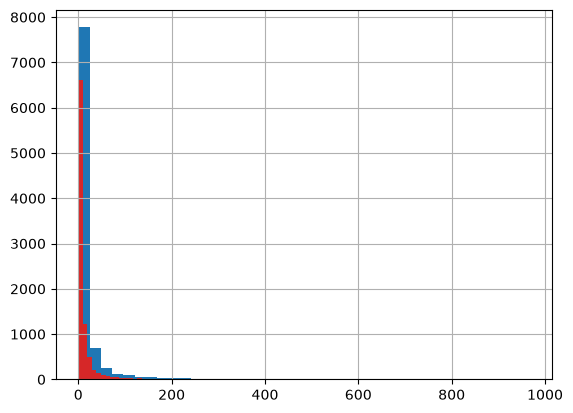

In [72]:
X["week_16_count"].hist(bins=40)
X["week_16_rel_freq"].hist(bins=40)
X["week_16_n_channels"].hist(bins=40)
X["week_16_n_videos"].hist(bins=40)

Text(0, 0.5, 'Target')

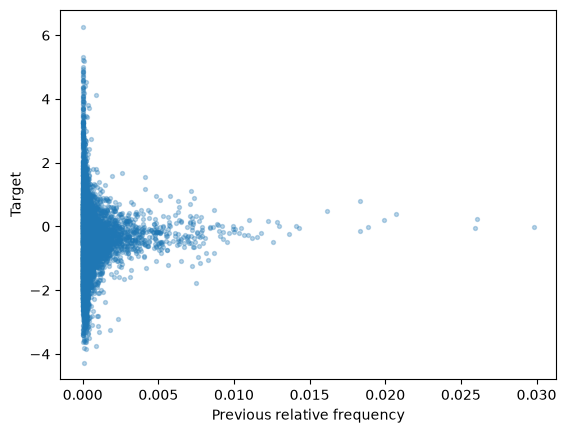

In [73]:
plt.scatter(
    X["week_16_rel_freq"],
    y,
    s=8,
    alpha=0.3
)
plt.xlabel("Previous relative frequency")
plt.ylabel("Target")

In [74]:
X.isna().sum().sort_values(ascending=False).head(20)

week_0_count                 0
n_channels_log_growth_3_2    0
n_videos_log_growth_5_4      0
n_videos_log_growth_6_5      0
n_videos_log_growth_7_6      0
n_videos_log_growth_8_7      0
n_videos_log_growth_9_8      0
n_videos_log_growth_10_9     0
n_videos_log_growth_11_10    0
n_videos_log_growth_12_11    0
n_videos_log_growth_13_12    0
n_videos_log_growth_14_13    0
n_videos_log_growth_15_14    0
n_videos_log_growth_16_15    0
n_channels_log_growth_1_0    0
n_channels_log_growth_2_1    0
n_channels_log_growth_4_3    0
n_videos_log_growth_3_2      0
n_channels_log_growth_5_4    0
n_channels_log_growth_6_5    0
dtype: int64

In [75]:
top_words = eval_df.nlargest(100, "y_true")["word"]

X_top = X.loc[top_words]
X_rest = X.drop(top_words)

top_means = X_top.mean()
rest_means = X_rest.mean()

comparison = pd.DataFrame({
    "top100_mean": top_means,
    "rest_mean": rest_means,
    "difference": top_means - rest_means,
    "ratio": top_means / (rest_means + 1e-10)
}).sort_values("difference", ascending=False)

comparison.head(30)

,top100_mean,rest_mean,difference,ratio
rel_freq_log_growth_10_9,2.260640,0.170095,2.090546,13.290486
rel_freq_log_growth_8_7,1.094843,-0.403199,1.498042,-2.715392
rel_likes_log_growth_8_7,0.748961,-0.670338,1.419299,-1.117288
rel_likes_log_growth_10_9,1.690438,0.325506,1.364932,5.193264
rel_freq_log_growth_16_15,1.477183,0.499559,0.977624,2.956973
rel_freq_log_growth_15_14,1.285378,0.316944,0.968433,4.055531
rel_freq_log_growth_1_0,1.070875,0.106058,0.964817,10.097093
rel_freq_log_growth_14_13,0.674513,-0.095320,0.769833,-7.076304
rel_likes_log_growth_15_14,0.703397,0.023458,0.679939,29.984874
avg_likes_log_growth_10_9,0.637519,-0.019146,0.656665,-33.298282


In [76]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    rf,
    X,
    y,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm = pd.DataFrame({
    "feature": X.columns,
    "importance": result.importances_mean
}).sort_values("importance", ascending=False)


In [77]:
perm.head(20)

,feature,importance
251,count_max,0.138811
252,rel_freq_mean,0.122052
101,week_16_rel_freq,0.071669
255,likes_mean,0.070206
16,week_16_count,0.070160
253,rel_freq_std,0.051688
67,week_16_n_videos,0.039268
262,rel_freq_momentum_3w,0.037857
41,week_7_avg_likes,0.019127
250,count_std,0.018721
